In [2]:
using Jens
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots
using Jens:LensCosmo as LC

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [3]:
using Jens.LensModel.ComLens: CombinedLens
using Jens.LensModel: NFWE, Shear
using Jens.LightModel: CompositeImage, ExtendedSource, PointImage
using Jens.LightModel.SersicLight: SersicSpheric
using Jens.LensSystem: ForwardModel, render

# Struct-like lens model

In [4]:
#=
                    质量侧                                     光度侧
            ┌──────────────────┐                    ┌──────────────────┐
  NFW  ──┐  │                  │                    │                  │
  Shear ─┼──▶ CombinedLens ────▶ LensedPlane ──┐    │  ExtendedSource ─┼──▶ CompositeImage
  SIS  ──┘  │  (线性叠加)       │  (D_ls/D_s)   │    │  PointImage      |    (同红移组合)
            └──────────────────┘               │    └──────────────────┘
                                               │              │
                                               ▼              ▼
                                        ┌──────────────────────────┐
                                        │       ForwardModel       │
                                        │  lens_plane  source_plane│
                                        │  psf          grid       │
                                        └──────────────────────────┘
                                               │
                                    render(sys; solver=:batch)
                                               │
                                    ┌──────────────────────┐
                                    │    rendered image    │
                                    │ (lensed + PSF + all) │
                                    └──────────────────────┘
=#

## Def Grid

In [5]:
grid = LensGenerator.GenGrid(pix_n=50, pix_size=0.03)

Jens.LensGenerator.Grid(50, 0.03, [-0.75 -0.75 … -0.75 -0.75; -0.72 -0.72 … -0.72 -0.72; … ; 0.72 0.72 … 0.72 0.72; 0.75 0.75 … 0.75 0.75], [-0.75 -0.72 … 0.72 0.75; -0.75 -0.72 … 0.72 0.75; … ; -0.75 -0.72 … 0.72 0.75; -0.75 -0.72 … 0.72 0.75])

## Lens model

### Cosmology

In [6]:
cosmo = LC.Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)

Cosmology.FlatLCDM{Float64}(0.7, 0.3, 0.0, 0.0)

### lens model

In [7]:
# Lens Struct
lens = CombinedLens(
    NFWE   => (Rs=1.5, alpha_Rs=1.0, e1=0.2, e2=0.3,  xcentre=0.2, ycentre=0.0),
    Shear => (gamma1=0.05, gamma2=-0.02, xcentre=0.0, ycentre=0.0),
)
# Lens Plane
z_lens = 0.3
lp = LensGenerator.LensedPlane(lens; z_lens=z_lens, cosmology=cosmo)

Jens.LensGenerator.LensedPlane{CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64, xcentre::Float64, ycentre::Float64}}}, Cosmology.FlatLCDM{Float64}}(CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64, xcentre::Float64, ycentre::Float64}}}((Jens.LensModel.NFWE, Jens.LensModel.Shear), ((Rs = 1.5, alpha_Rs = 1.0, e1 = 0.2, e2 = 0.3, xcentre = 0.2, ycentre = 0.0), (gamma1 = 0.05, gamma2 = -0.02, xcentre = 0.0, ycentre = 0.0))), 0.3, Cosmology.FlatLCDM{Float64}(0.7, 0.3, 0.0, 0.0))

## Light model

### Lens Light

In [8]:
lens_light = ExtendedSource(SersicSpheric;
    amp = 1, Rsersic = 0.8, n = 4.0,    
    xcentre = 0.0, ycentre = -0.05,
)

ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.0, Rsersic = 0.8, n = 4.0, xcentre = 0.0, ycentre = -0.05))

### Source light

In [9]:
host = ExtendedSource(SersicSpheric;
    amp = 1.5, Rsersic = 0.8, n = 1.0,     
    xcentre = 0.0, ycentre = 0.0,
)
agn = PointImage(flux=2.0, beta_x=0.0, beta_y=0.0)
# source light ==>  host galaxy(Sersic) + AGN(Point-source)
z_source = 1.0
src = CompositeImage(host, agn)

CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImage}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.5, Rsersic = 0.8, n = 1.0, xcentre = 0.0, ycentre = 0.0)), PointImage(2.0, 0.0, 0.0)))

In [10]:
mlp = LensGenerator.MultiLightPlane(
    lens_light => z_lens,   
    src  => z_source,    
)

Jens.LensGenerator.MultiLightPlane{Tuple{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, Float64}, Tuple{CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImage}}, Float64}}}(((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.0, Rsersic = 0.8, n = 4.0, xcentre = 0.0, ycentre = -0.05)), 0.3), (CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImage}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.5, Rsersic = 0.8, n = 1.

## PSF

In [11]:
psf  = WFC3.WFC3_UVIS_PSF(lambda_eff=606e-9)

Jens.WFC3.WFC3_UVIS_PSF(6.06e-7, 5)

## Lens System

In [12]:
sys = ForwardModel(
    lens_plane = lp,
    source_plane = mlp,
    grid = grid,
    psf = psf,
)

ForwardModel{Jens.LensGenerator.LensedPlane{CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64, xcentre::Float64, ycentre::Float64}}}, Cosmology.FlatLCDM{Float64}}, Jens.LensGenerator.MultiLightPlane{Tuple{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, Float64}, Tuple{CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImage}}, Float64}}}, Jens.WFC3.WFC3_UVIS_PSF, Jens.LensGenerator.Grid}(Jens.LensGenerator.LensedPlane{CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64, xcentre::Float64, ycentre::Float64}}}, Cos

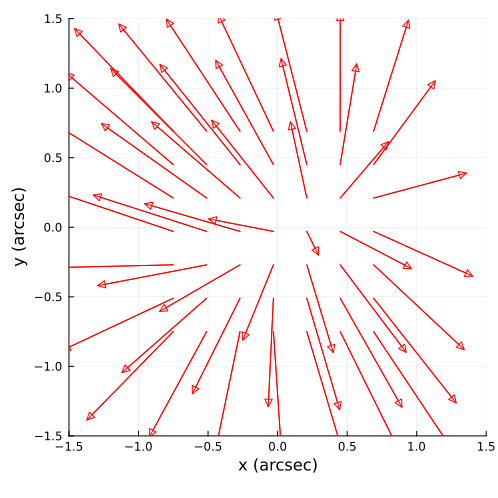

In [18]:
# deflection angle
ax,ay, = LB.lens_derivative(sys.lens_plane.lens, sys.grid.xg, sys.grid.yg)

deflectionc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
                size=(500,500))
Jplots.PlotVec!(deflectionc, sys.grid.xg, sys.grid.yg, ax, ay; step=8,
    color=:red, linewidth=1, arrow=Jplots.arrow(:open, 0.3))
display(deflectionc)

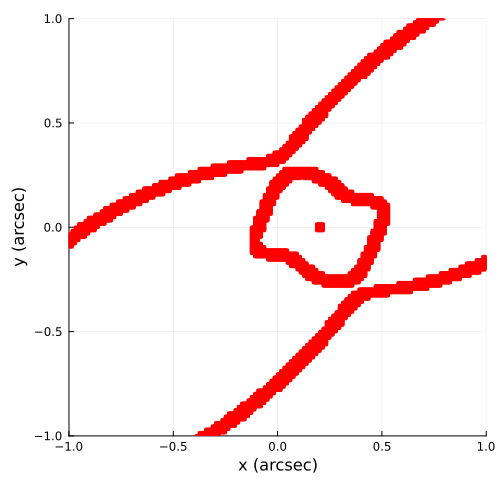

In [ ]:
# critical curve
ccx, ccy = LB.LensAdaptiveCriticalCurve(; LensModel=sys.lens_plane.lens,
             LensKwargs=NamedTuple(), max_depth=5)
# Larger max_depth will enhence the results, but the file is too large to show on Github

ccc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
                size=(500,500))
Jplots.PlotPoints!(ccc, ccx, ccy)
display(ccc)

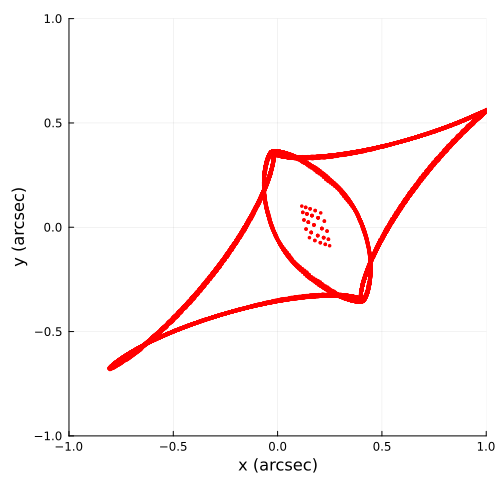

In [ ]:
# caustic
csx, csy = LB.LensAdaptiveCaustic(; LensModel=sys.lens_plane.lens,
         LensKwargs=NamedTuple(), max_depth=5)
# Larger max_depth will enhence the results, but the file is too large to show on Github

csc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
                size=(500,500))
Jplots.PlotPoints!(csc, csx, csy)
display(csc)

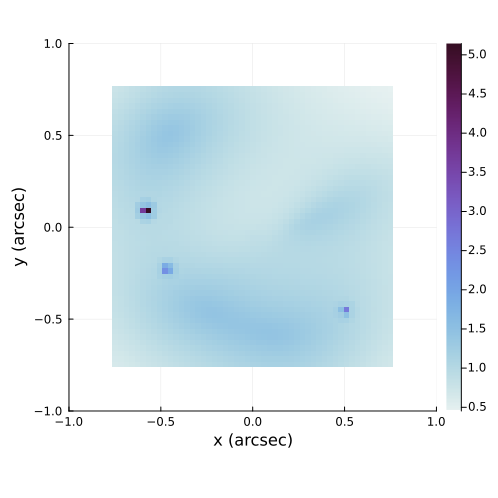

In [16]:
# image
img = render(sys)

imgc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
                size=(500,500))
Jplots.PlotPlane!(imgc, sys.grid.xg, sys.grid.yg, img)
display(imgc)